In [ ]:
import lightgbm as lgb
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
import polars as pl
import numpy as np
import optuna
import pandas as pd

In [2]:
from pathlib import Path

path = Path.cwd()
if not Path(path, "data").exists():
    path = path.parent

In [3]:
df_train = pl.read_parquet(path / "data" / "train_tip_clean.parquet")
df_val = pl.read_parquet(path / "data" / "val_tip_clean.parquet")
df_test = pl.read_parquet(path / "data" / "test_tip_clean.parquet")

In [5]:
df_train.head()

pickup_datetime,PULocationID,DOLocationID,tip_amount,VendorID,fare_amount,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,pickup_dist_nyc,dropoff_dist_nyc,pickup_dist_chp,dropoff_dist_chp,pickup_dist_exp,dropoff_dist_exp,distance,direction,temperature_2m,precipitation,rain,snowfall,temp_discomfort,is_raining,daylight_duration,is_daylight,month,dayofyear,weekday,hour
datetime[μs],i16,i16,i16,i8,i16,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,f64,i32,i8,i16,i8,f64
2025-08-02 20:19:10,132,50,1634,0,7000,40.646984,-73.78653,40.766239,-73.995132,26828.321701,5137.460747,134587.515893,138770.678374,31092.735952,6939.110049,30878.875895,-52.910512,21.9,0.0,0.0,0.0,1.9,0,51397.94,0,8,214,6,20.316667
2025-08-02 20:40:51,79,50,539,0,2120,40.727619,-73.985939,40.766239,-73.995132,1614.017032,5137.460747,142319.163361,138770.678374,5282.39014,6939.110049,5074.514422,-10.220136,21.9,0.0,0.0,0.0,1.9,0,51397.94,0,8,214,6,20.666667
2025-08-14 22:10:32,79,263,300,0,1980,40.727619,-73.985939,40.778767,-73.951012,1614.017032,10252.663773,142319.163361,133666.564799,5282.39014,12053.718033,8639.093407,27.341037,27.0,0.0,0.0,0.0,7.0,0,49787.86,0,8,226,4,22.166667
2025-08-14 22:40:10,246,263,525,0,2050,40.753307,-74.004013,40.778767,-73.951012,3365.915603,10252.663773,140962.749219,133666.564799,4750.9054,12053.718033,7302.771441,57.59878,27.0,0.0,0.0,0.0,7.0,0,49787.86,0,8,226,4,22.666667
2025-08-28 11:54:26,50,50,197,0,510,40.766239,-73.995132,40.766239,-73.995132,5137.460747,5137.460747,138770.678374,138770.678374,6939.110049,6939.110049,0.0,0.0,23.5,0.0,0.0,0.0,3.5,0,47706.39,1,8,240,4,11.9


In [5]:
categorical_cols = [
    "VendorID",
    "weekday",
    "month",
    "PULocationID",
    "DOLocationID",
    "is_raining",
    "is_daylight"
]
input_cols = [col for col in df_train.columns if col not in ["tip_amount",'pickup_datetime','payment_type', "sunrise", "sunset"]]

x_train, y_train = df_train.select(input_cols), df_train.select("tip_amount").to_numpy()
x_test, y_test = df_test.select(input_cols), df_test.select("tip_amount").to_numpy()
x_val, y_val = df_val.select(input_cols), df_val.select("tip_amount").to_numpy()

## Prueba con rmse

In [5]:
train_data = lgb.Dataset(
    data=x_train,
    label=y_train,
    feature_name=input_cols,
    categorical_feature=categorical_cols,
    free_raw_data=True,
)

val_data = lgb.Dataset(
    data=x_val, label=y_val, reference=train_data, feature_name=input_cols
)

lgbm_params = {
    "objective": "tweedie",
    "boosting": "gbdt",
    "metric": "rmse",
    "verbose": -1,
    "tweedie_variance_power": 1.55, 
    "learning_rate": 0.05, 
    "num_leaves": 150, 
    "max_depth": 10,
    "min_data_in_leaf": 1000, 
    "feature_fraction": 0.8, 
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l2": 1.0, 
    "max_bin": 255,
}

model_lgb = lgb.train(
    params=lgbm_params,
    train_set=train_data,
    num_boost_round=5000,
    valid_sets=[train_data, val_data],
    valid_names=["Entrenamiento", "Validacion"],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)],
)

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")


Training until validation scores don't improve for 50 rounds
[100]	Entrenamiento's rmse: 239.443	Validacion's rmse: 237.335
[200]	Entrenamiento's rmse: 238.248	Validacion's rmse: 236.636
Early stopping, best iteration is:
[221]	Entrenamiento's rmse: 238.102	Validacion's rmse: 236.498


In [ ]:
model_lgb.save_model(path / "data" / "lgbm_rmse236.498_tip_clean.txt")

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

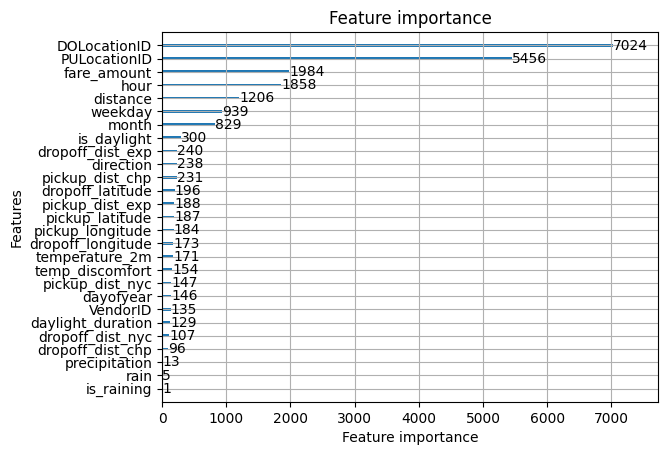

In [7]:
lgb.plot_importance(model_lgb)

Prácticamente está agrupando por locationID y prediciendo la media.

In [11]:
def evaluar_modelo(y_true, y_pred, nombre_set="Test"):
    """
    Evalúa predicciones de regresión y devuelve un diccionario con las métricas.
    Soporta entradas como Series de Polars, listas o arrays de NumPy.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    media_real = np.mean(y_true)
    media_pred = np.mean(y_pred)

    print(f"\n--- REPORTE DE RENDIMIENTO: {nombre_set} ---")
    print(f"MAE  (Error Absoluto Medio):       {mae:.4f}")
    print(f"RMSE (Raíz del Error Cuadrático):  {rmse:.4f}")
    print(f"R²   (Coef. de Determinación):     {r2:.4f}")
    print("-" * 45)
    print(f"Propina media real del set:        {media_real:.4f}")
    print(f"Propina media predicha:            {media_pred:.4f}")
    print("-" * 45)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Media_Real": media_real,
        "Media_Pred": media_pred,
    }


In [ ]:
predicciones = model_lgb.predict(x_val)
metricas_finales = evaluar_modelo(
    y_val, predicciones, nombre_set="Tip (val) con rmse"
)

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")



--- REPORTE DE RENDIMIENTO: Tip (val) con rmse ---
MAE  (Error Absoluto Medio):       131.9703
RMSE (Raíz del Error Cuadrático):  236.4985
R²   (Coef. de Determinación):     0.6225
---------------------------------------------
Propina media real del set:        416.9380
Propina media predicha:            411.9059
---------------------------------------------


## Entrenamiento con huber

In [17]:
train_data = lgb.Dataset(
    data=x_train,
    label=y_train,
    feature_name=input_cols,
    categorical_feature=categorical_cols,
    free_raw_data=True,
)

val_data = lgb.Dataset(
    data=x_val, label=y_val, reference=train_data, feature_name=input_cols
)

lgbm_params = {
    "objective": "huber",          # Cambiado de tweedie a huber
    "metric": "huber",             # Coherencia entre objetivo y métrica
    "boosting": "gbdt",
    "verbose": -1,
    "alpha": 0.9,
    "learning_rate": 0.05,
    "num_leaves": 128,             # Bajamos de 268 para evitar sobreajuste
    "max_depth": 10,               # Profundidad controlada
    "min_data_in_leaf": 1000,      # Mayor estabilidad estadística
    "feature_fraction": 0.7,
    "bagging_fraction": 0.8,       # Usamos el 80% de las filas
    "bagging_freq": 5,
    "lambda_l1": 0.1,              # Añadimos un poco de L1 para limpiar ruido
    "lambda_l2": 1.0,              # L2 para suavizar pesos
    
    "max_bin": 255,
}
model_lgb_huber = lgb.train(
    params=lgbm_params,
    train_set=train_data,
    num_boost_round=5000,
    valid_sets=[train_data, val_data],
    valid_names=["Entrenamiento", "Validacion"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, first_metric_only=False, verbose=True),
        lgb.log_evaluation(period=50),
    ],
)

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")


Training until validation scores don't improve for 50 rounds
[50]	Entrenamiento's huber: 225.19	Validacion's huber: 222.009
[100]	Entrenamiento's huber: 224.038	Validacion's huber: 220.899
[150]	Entrenamiento's huber: 222.866	Validacion's huber: 219.769
[200]	Entrenamiento's huber: 221.719	Validacion's huber: 218.664
[250]	Entrenamiento's huber: 220.546	Validacion's huber: 217.532
[300]	Entrenamiento's huber: 219.406	Validacion's huber: 216.435
[350]	Entrenamiento's huber: 218.296	Validacion's huber: 215.369
[400]	Entrenamiento's huber: 217.16	Validacion's huber: 214.278
[450]	Entrenamiento's huber: 216.008	Validacion's huber: 213.173
[500]	Entrenamiento's huber: 214.911	Validacion's huber: 212.122
[550]	Entrenamiento's huber: 213.802	Validacion's huber: 211.062
[600]	Entrenamiento's huber: 212.688	Validacion's huber: 209.996
[650]	Entrenamiento's huber: 211.581	Validacion's huber: 208.935
[700]	Entrenamiento's huber: 210.483	Validacion's huber: 207.883
[750]	Entrenamiento's huber: 209

In [25]:
model_lgb.save_model(path / "data" / "lgbm_huber152.94_tip_clean.txt")

In [19]:
predicciones = model_lgb_huber.predict(x_val)
metricas_finales = evaluar_modelo(
    y_val, predicciones, nombre_set="Tip (val) con huber"
)

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")



--- REPORTE DE RENDIMIENTO: Tip (val) con huber ---
MAE  (Error Absoluto Medio):       170.3816
RMSE (Raíz del Error Cuadrático):  325.4697
R²   (Coef. de Determinación):     0.2850
---------------------------------------------
Propina media real del set:        416.9380
Propina media predicha:            382.2265
---------------------------------------------


Prácticamente el mismo resultado.

## Búsqueda con optuna

In [22]:
import optuna
import lightgbm as lgb
from sklearn.metrics import root_mean_squared_error
from optuna.integration import LightGBMPruningCallback

# 1. CREAMOS LOS DATASETS FUERA
train_data = lgb.Dataset(
    data=x_train, 
    label=y_train, 
    feature_name=input_cols, 
    categorical_feature=categorical_cols, 
    free_raw_data=False
)

val_data = lgb.Dataset(
    data=x_val, 
    label=y_val, 
    reference=train_data, 
    feature_name=input_cols, 
    free_raw_data=False
)

best_rmse = 236.5472

def objective(trial):
    global best_rmse

    # --- TRUCO DE EXPERTO: Acoplar hojas a profundidad ---
    # Una profundidad de 'd' tiene un máximo teórico de 2^d hojas.
    # Evitamos que Optuna sugiera 500 hojas para una profundidad de 5 (lo cual da error/warnings).
    max_depth = trial.suggest_int("max_depth", 6, 14)
    max_leaves_possible = (2 ** max_depth) - 1
    num_leaves = trial.suggest_int("num_leaves", 32, min(max_leaves_possible, 256))

    # Definimos el espacio de búsqueda (Refinado)
    param = {
        "objective": "tweedie",
        "metric": "rmse",
        "verbosity": -1,
        "boosting_type": "gbdt",
        
        # Acotamos el Tweedie cerca de tu valor óptimo conocido
        "tweedie_variance_power": trial.suggest_float("tweedie_variance_power", 1.4, 1.7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        
        "num_leaves": num_leaves,
        "max_depth": max_depth,
        
        # Subimos el mínimo para evitar sobreajustar el ruido de NY y el clima
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 500, 2000), 
        
        # Acotamos los rangos inferiores para que siempre vea suficientes variables
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 5),
        
        # Subimos el límite inferior de la regularización L1/L2
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-3, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-3, 10.0, log=True),
    }

    # --- EL CALLBACK DE PODA (PRUNING) ---
    # Le decimos a Optuna que vigile la métrica "rmse" en el set "valid_0"
    pruning_callback = LightGBMPruningCallback(trial, "rmse", valid_name="valid_0")

    # Entrenamos el modelo
    model = lgb.train(
        params=param,
        train_set=train_data,
        num_boost_round=2000,
        valid_sets=[val_data],
        valid_names=["valid_0"], # Nombre explícito para que el Pruner no se pierda
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            pruning_callback # Metemos la tijera aquí
        ],
    )

    preds = model.predict(x_val)
    rmse = root_mean_squared_error(y_val, preds)
    
    if rmse < best_rmse:
        best_rmse = rmse
        model.save_model("mejor_modelo_lgbm_optimizado.txt")
        print(f"🌟 ¡Nuevo récord! RMSE bajó a {best_rmse:.4f}. Modelo guardado.")

    return rmse

# --- INICIAMOS EL STUDY CON UN PRUNER ACTIVO ---
print("Iniciando búsqueda de hiperparámetros con Optuna y Pruning...")
# El MedianPruner deja un "calentamiento" de 20 rondas antes de empezar a asesinar trials
study = optuna.create_study(
    direction="minimize", 
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=50) 
)
study.optimize(objective, n_trials=10) 

print("\n" + "="*50)
print("🏆 BÚSQUEDA TERMINADA 🏆")
print("="*50)
for k, v in study.best_params.items():
    print(f"  - {k}: {v}")

[I 2026-04-23 09:01:52,574] A new study created in memory with name: no-name-33ee6468-a021-4de1-95dd-6cd75b89314e


Iniciando búsqueda de hiperparámetros con Optuna y Pruning...


c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-04-23 09:02:43,424] Trial 0 finished with value: 236.51398222282546 and parameters: {'max_depth': 14, 'num_leaves': 66, 'tweedie_variance_power': 1.575612617670735, 'learning_rate': 0.03360779545400284, 'min_data_in_leaf': 1691, 'feature_fraction': 0.707036369780286, 'bagging_fraction': 0.6811540449108145, 'bagging_freq': 5, 'lambda_l1': 0.8310285430233695, 'lambda_l2': 0.014912039691021957}. Best is trial 0 with value: 236.51398222282546.


🌟 ¡Nuevo récord! RMSE bajó a 236.5140. Modelo guardado.


c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-04-23 09:04:28,307] Trial 1 finished with value: 237.54526631803344 and parameters: {'max_depth': 6, 'num_leaves': 35, 'tweedie_variance_power': 1.4374432821324512, 'learning_rate': 0.017562331503455555, 'min_data_in_leaf': 1541, 'feature_fraction': 0.8994292242484547, 'bagging_fraction': 0.881132668685359, 'bagging_freq': 3, 'lambda_l1': 0.2910719996006418, 'lambda_l2': 0.018110788929772588}. Best is trial 0 with value: 236.51398222282546.
c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
[I 2026-04-23 09:04:50,857] Trial 2 finished with value: 236.9016217792018 and parameters: {'max_depth': 11, 'num_leaves': 147, 'tweedie_va


🏆 BÚSQUEDA TERMINADA 🏆
  - max_depth: 14
  - num_leaves: 66
  - tweedie_variance_power: 1.575612617670735
  - learning_rate: 0.03360779545400284
  - min_data_in_leaf: 1691
  - feature_fraction: 0.707036369780286
  - bagging_fraction: 0.6811540449108145
  - bagging_freq: 5
  - lambda_l1: 0.8310285430233695
  - lambda_l2: 0.014912039691021957


In [ ]:
model_optuna = lgb.Booster(model_file="mejor_modelo_lgbm.txt")
predicciones = model_optuna.predict(x_val)
metricas_finales = evaluar_modelo(
    y_val, predicciones, nombre_set="Tip (val) optuna"
)


--- REPORTE DE RENDIMIENTO: Tip (val) optuna ---
MAE  (Error Absoluto Medio):       132.0177
RMSE (Raíz del Error Cuadrático):  239.9022
R²   (Coef. de Determinación):     0.6116
---------------------------------------------
Propina media real del set:        416.9380
Propina media predicha:            413.2933
---------------------------------------------


## Validación final en test

El mejor modelo es el de rmse que entrenamos al principio.

In [13]:


# 1. CARGAR EL MODELO
# No necesitas definir parámetros ni nada, se lee directamente del disco
model_final = lgb.Booster(model_file=path / "data" / "lgbm_rmse236.498_tip_clean.txt")

In [14]:
predicciones = model_final.predict(x_test)
metricas_finales = evaluar_modelo(
    y_test, predicciones, nombre_set="Tip (val) optuna"
)

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")



--- REPORTE DE RENDIMIENTO: Tip (val) optuna ---
MAE  (Error Absoluto Medio):       135.8699
RMSE (Raíz del Error Cuadrático):  254.4015
R²   (Coef. de Determinación):     0.6004
---------------------------------------------
Propina media real del set:        419.8779
Propina media predicha:            413.3482
---------------------------------------------
